# 05 - Gözetimsiz Makine Öğrenmesi (Unsupervised Learning)
## Uydu Telemetri Anomali Tespiti

**Amaç:** Etiket kullanmadan anomali tespiti. Modeller sadece Normal verilerle eğitilir.

### Modeller:
1. Isolation Forest
2. One-Class SVM
3. K-Means Clustering
4. Local Outlier Factor (LOF)
5. Autoencoder (Derin Öğrenme)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json, warnings, joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Kütüphaneler yüklendi.')


Kütüphaneler yüklendi.


---
## Bölüm 0: Veri Hazırlama


In [2]:
# ── KANONİK veri hazırlama: resmi split + 18 ESA özelliği (leakage-free) ──
# Bu notebook gösterim amaçlıdır; kanonik gözetimsiz modeller/eşikler train_all_models.py
# tarafından üretilir (bu notebook onları EZMEZ). Gözetimsiz protokol: YALNIZ normal (T) ile eğit.
ESA_18_FEATURES = [
    'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks',
    'duration', 'len', 'gaps_squared', 'len_weighted',
    'var_div_duration', 'var_div_len',
    'smooth10_n_peaks', 'smooth20_n_peaks',
    'diff_peaks', 'diff2_peaks', 'diff_var', 'diff2_var',
]
dataset = pd.read_csv('../data/raw/dataset.csv')
feature_cols = ESA_18_FEATURES

train_df = dataset[dataset['train'] == 1].copy()
test_df  = dataset[dataset['train'] == 0].copy()
X_train_full = train_df[feature_cols].fillna(0)
y_train_full = train_df['anomaly'].reset_index(drop=True)
X_test = test_df[feature_cols].fillna(0)
y_test = test_df['anomaly'].reset_index(drop=True)

# T'den validation ayır (Ψ dokunulmaz); scaler YALNIZ T'de fit (leakage-free)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Gözetimsiz protokol: model YALNIZCA normal örneklerle eğitilir
normal_mask = (y_tr == 0).values
X_normal_train = X_tr_s[normal_mask]

print(f"Resmi split — T: {len(y_train_full)}, Ψ: {len(y_test)} | 18 özellik")
print(f"Eğitim (yalnız Normal): {X_normal_train.shape}, Val: {X_val_s.shape}, Test Ψ: {X_test_s.shape}")

def find_best_threshold(scores, y_true):
    best_f1, best_t = 0, np.percentile(scores, 90)
    for p in np.arange(40, 99.5, 0.5):
        t = np.percentile(scores, p)
        preds = (scores > t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1

Resmi split — T: 1594, Ψ: 529 | 18 özellik
Eğitim (yalnız Normal): (1081, 18), Val: (240, 18), Test Ψ: (529, 18)


---
## Bölüm 1: Isolation Forest


              precision    recall  f1-score   support

      Normal       0.84      0.78      0.81       416
     Anomali       0.35      0.43      0.39       113

    accuracy                           0.71       529
   macro avg       0.59      0.61      0.60       529
weighted avg       0.73      0.71      0.72       529

AUC: 0.6836


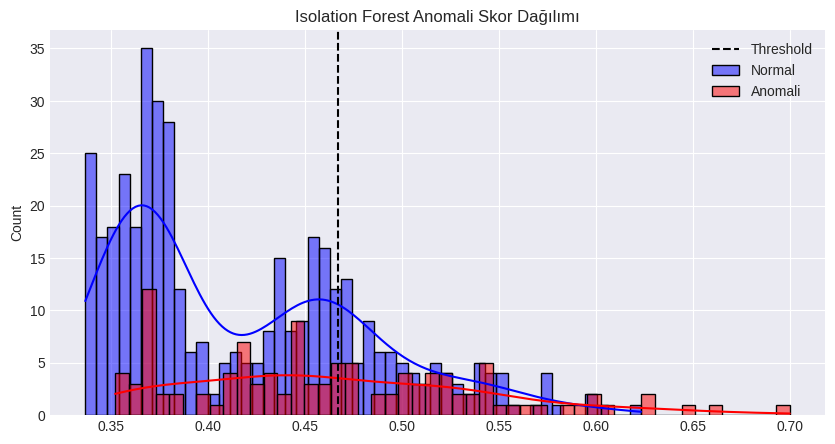

In [3]:
iso = IsolationForest(n_estimators=200, max_features=0.75, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_normal_train)

scores_val = -iso.score_samples(X_val_s)
iso_thresh, val_f1 = find_best_threshold(scores_val, y_val.values)
scores_test = -iso.score_samples(X_test_s)
y_pred = (scores_test > iso_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=iso_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomali Skor Dağılımı'); plt.legend(); plt.show()


---
## Bölüm 2: One-Class SVM


In [4]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm.fit(X_normal_train)
scores_val = -ocsvm.decision_function(X_val_s)
ocsvm_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -ocsvm.decision_function(X_test_s)
y_pred = (scores_test > ocsvm_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")


              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94       416
     Anomali       0.91      0.59      0.72       113

    accuracy                           0.90       529
   macro avg       0.90      0.79      0.83       529
weighted avg       0.90      0.90      0.89       529

AUC: 0.7611


---
## Bölüm 3: K-Means Clustering


In [5]:
km = KMeans(n_clusters=10, random_state=42, n_init='auto')
km.fit(X_normal_train)
scores_val = np.min(km.transform(X_val_s), axis=1)
km_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = np.min(km.transform(X_test_s), axis=1)
y_pred = (scores_test > km_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

from sklearn.decomposition import PCA
pca = PCA(n_components=3); X_pca = pca.fit_transform(X_test_s)
fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2], color=y_test.astype(str),
                    color_discrete_map={'0':'blue','1':'red'}, opacity=0.6,
                    title="K-Means: 3D PCA Anomali Ayrışması")
fig.update_layout(template='plotly_dark'); fig.show()


              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91       416
     Anomali       0.68      0.62      0.65       113

    accuracy                           0.86       529
   macro avg       0.79      0.77      0.78       529
weighted avg       0.85      0.86      0.85       529

AUC: 0.8513


---
## Bölüm 4: Local Outlier Factor (LOF)


In [6]:
lof = LocalOutlierFactor(n_neighbors=10, novelty=True, contamination=float(y_tr.mean()))
lof.fit(X_normal_train)
scores_val = -lof.score_samples(X_val_s)
lof_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -lof.score_samples(X_test_s)
y_pred = (scores_test > lof_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       416
     Anomali       0.84      0.86      0.85       113

    accuracy                           0.94       529
   macro avg       0.90      0.91      0.90       529
weighted avg       0.94      0.94      0.94       529

AUC: 0.9590


---
## Bölüm 5: Autoencoder (Derin Öğrenme)


I0000 00:00:1780778609.400645   50904 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780778609.428123   50904 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1780778610.433022   50904 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780778612.148333   50904 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/150


 1/34 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 2.3138

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3047 - val_loss: 0.7488


...

 1/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0764

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0962 - val_loss: 0.2436


Epoch 26/150


 1/34 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0568

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1013 - val_loss: 0.4004


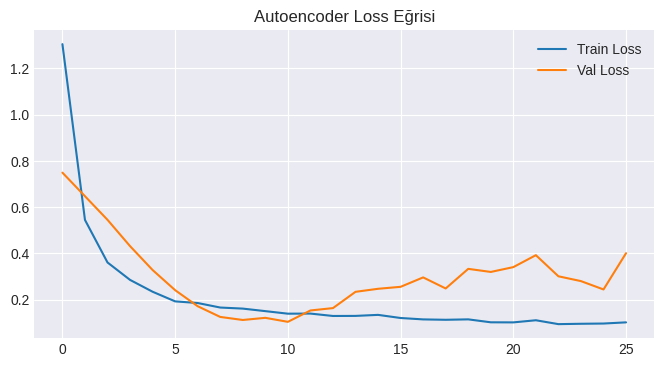

              precision    recall  f1-score   support

      Normal       0.91      0.96      0.93       416
     Anomali       0.81      0.65      0.73       113

    accuracy                           0.89       529
   macro avg       0.86      0.81      0.83       529
weighted avg       0.89      0.89      0.89       529

AUC: 0.9267


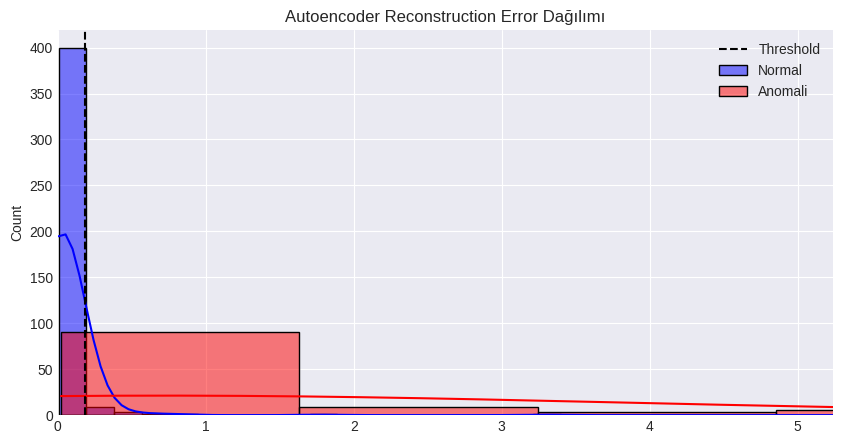

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

ae = Sequential([
    Dense(64, activation='relu', input_shape=(X_normal_train.shape[1],)),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(64, activation='relu'), BatchNormalization(),
    Dense(X_normal_train.shape[1], activation='linear')
])
ae.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
X_normal_val = X_val_s[y_val.values == 0]
history = ae.fit(X_normal_train, X_normal_train, validation_data=(X_normal_val, X_normal_val),
                 epochs=150, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)], verbose=1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss Eğrisi'); plt.legend(); plt.show()

recon_val = ae.predict(X_val_s, verbose=0)
scores_val = np.mean(np.power(X_val_s - recon_val, 2), axis=1)
ae_thresh, _ = find_best_threshold(scores_val, y_val.values)
recon_test = ae.predict(X_test_s, verbose=0)
scores_test = np.mean(np.power(X_test_s - recon_test, 2), axis=1)
y_pred = (scores_test > ae_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=ae_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Autoencoder Reconstruction Error Dağılımı')
plt.xlim([0, np.percentile(scores_test, 98)]); plt.legend(); plt.show()


---
## Bölüm 6: ROC Karşılaştırması


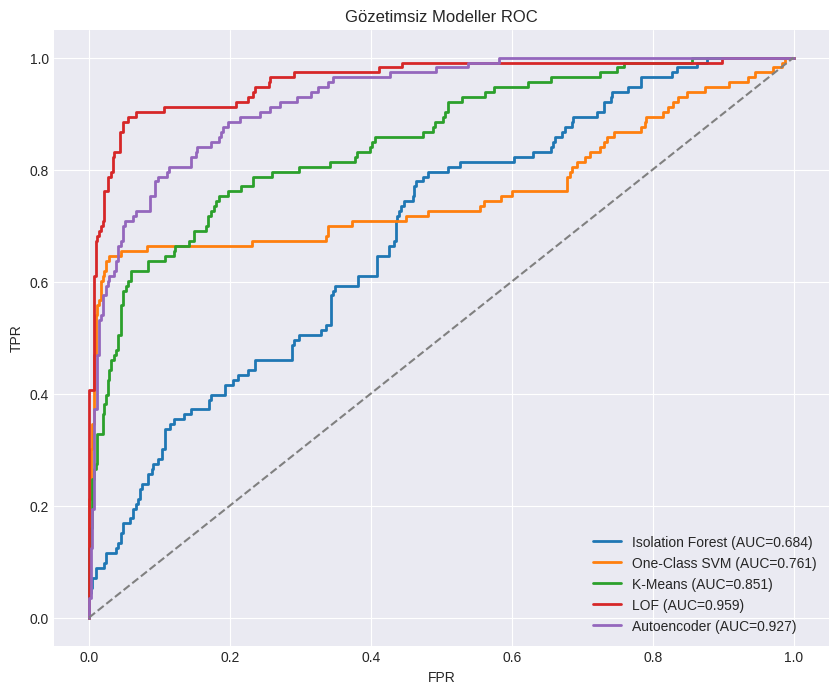

In [8]:
plt.figure(figsize=(10, 8))
all_scores = {
    'Isolation Forest': -iso.score_samples(X_test_s),
    'One-Class SVM': -ocsvm.decision_function(X_test_s),
    'K-Means': np.min(km.transform(X_test_s), axis=1),
    'LOF': -lof.score_samples(X_test_s),
    'Autoencoder': np.mean(np.power(X_test_s - ae.predict(X_test_s, verbose=0), 2), axis=1)
}
for name, sc in all_scores.items():
    fpr,tpr,_ = roc_curve(y_test, sc); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Gözetimsiz Modeller ROC'); plt.legend(loc='lower right')
plt.show()


---
## Bölüm 7: Kaydetme


In [9]:
# NOT: Kanonik gözetimsiz model dosyaları ve unsupervised_thresholds.json,
# train_all_models.py tarafından resmi split + 18 özellik ile üretilir. Bu gösterim
# notebook'u onları EZMEZ. Yukarıdaki modeller yalnızca in-notebook analiz/görselleştirme
# içindir; kanonik 18 gözetimsiz dedektörün 7-metrik karşılaştırması için NB06'ya bakınız.
print("Kanonik gözetimsiz artefaktlar train_all_models.py'den gelir (bkz. NB06).")

Kanonik gözetimsiz artefaktlar train_all_models.py'den gelir (bkz. NB06).


---
## Ek Gözetimsiz Modeller (sklearn + Derin + PyOD)

Mevcut 5 modele ek olarak **9 yeni gözetimsiz dedektör**:

**sklearn / derin (5):** GMM, Elliptic Envelope, PCA (reconstruction error), DBSCAN (core-distance novelty), VAE

**PyOD (4):** ECOD, COPOD, HBOS, CBLOF — *yalnızca `pip install pyod` kuruluysa eğitilir.*

In [10]:
# SÜPERSEDED: Ek gözetimsiz dedektörler (GMM, Elliptic Envelope, PCA, DBSCAN, VAE +
# PyOD: ECOD/COPOD/HBOS/CBLOF/ABOD/COF/SOD/SOS/LMDD/LODA/INNE) artık train_all_models.py
# tarafından KANONIK (resmi split, 18 özellik) eğitilip kaydedilir ve eşikleri
# unsupervised_thresholds.json'a yazılır. Bu hücre kanonik artefaktları EZMEMEK için devre dışı.
print("Ek gözetimsiz modeller train_all_models.py'de kanonik eğitiliyor (bkz. NB06).")

Ek gözetimsiz modeller train_all_models.py'de kanonik eğitiliyor (bkz. NB06).


### HTML Rapor


In [11]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 05_model_unsupervised.ipynb --output ../reports/05_model_unsupervised_rapor.html



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/bin/python3.11 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
/bin/bash: line 1: jupyter: command not found
